In [1]:
import os
import sys
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
torch.manual_seed(42)

src_path = os.path.abspath('/home/fabihat/phd_quaid/2603_dl_prj/ATAC_denoising/src')
#src_path = os.path.abspath('/data1/peerd/paddockl/projects/DL_project/ATAC_denoising/src')
sys.path.append(src_path)

from atac_dataset import create_dataloader
from model import VAE
from plot import plot_bin_counts, plot_bin_counts_single

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
#dataloader = create_dataloader(dense_dir = "/data1/peerd/paddockl/projects/DL_project/ATAC_denoising/data/ENCODE_ATAC_chr19_Counts",
#                              sparse_dir = "/data1/peerd/paddockl/projects/DL_project/ATAC_denoising/data/atac_chr19_subsampled",
#                              batch_size = 7,
#                              num_workers = 2,
#                              sparsity = 0.5)

train_loader, val_loader = create_dataloader(atac_dir = "/home/fabihat/phd_quaid/2603_dl_prj/data/atac_chr19_subsampled",
                               batch_size = 6,
                               num_workers = 2,
                               sparsity = 50)

/home/fabihat/micromamba/envs/DL_project/lib/python3.13/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/home/fabihat/micromamba/envs/DL_project/lib/python3.13/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


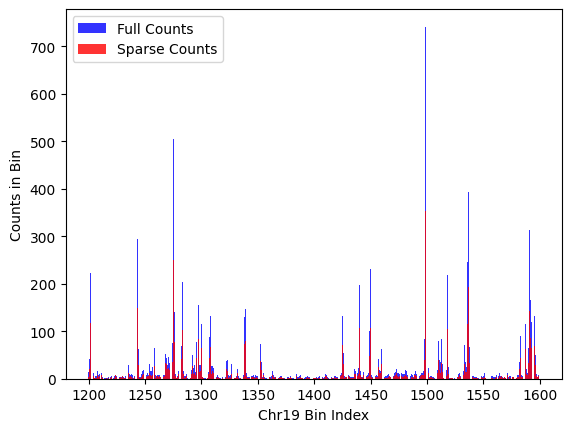

In [3]:
x, y = next(iter(train_loader))
f = plot_bin_counts(x[0],y[0], bin_range = (1200,1600))

In [4]:
x, y = next(iter(train_loader))

/home/fabihat/phd_quaid/2603_dl_prj/ATAC_denoising/src/plot.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


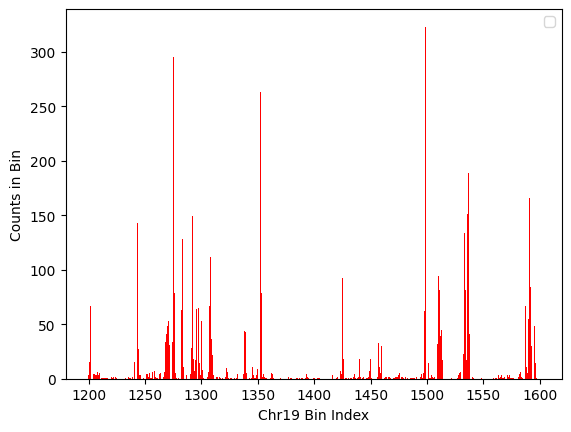

In [5]:
f = plot_bin_counts_single(x[0], bin_range = (1200,1600), color="red")

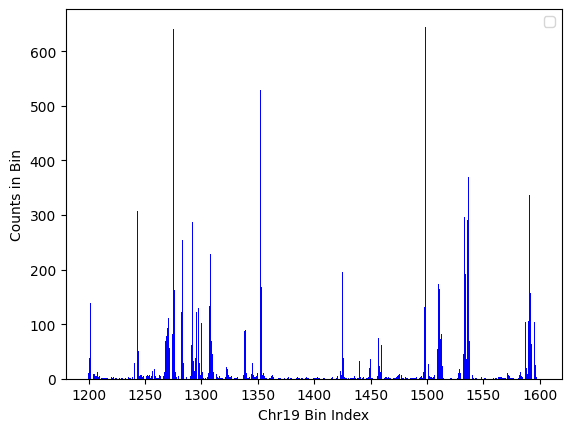

In [6]:
f = plot_bin_counts_single(y[0], bin_range = (1200,1600), color="blue")

In [8]:
#Epoch 077 | Train Loss: 349.6134 | Val Loss: 732.8058 | Recon: 349.2100 | KL: 0.5308 | Beta: 0.7600

In [2]:

def vae_loss(x_hat, x, mu, logvar, beta=1.0, pos_weight=5.0):
    recon_loss = F.mse_loss(x_hat, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl, recon_loss, kl
"""

def vae_loss(x, mu, theta, z_mu, logvar, beta=1.0, eps=1e-8):
    log_theta_mu = torch.log(theta + mu + eps)

    ll = (
        theta * (torch.log(theta + eps) - log_theta_mu)
        + x * (torch.log(mu + eps) - log_theta_mu)
        + torch.lgamma(x + theta)
        - torch.lgamma(theta)
        - torch.lgamma(x + 1)
    )

    recon_loss = -ll.mean()
    kl = -0.5 * torch.mean(1 + logvar - z_mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl, recon_loss, kl
"""
def train_vae(
    model,
    train_loader,
    val_loader,
    device,
    model_save_dir,
    epochs=500,
    lr=1e-3,
    beta_start=0.0,
    beta_end=1.0,
    beta_warmup=100,
    patience=20,
    min_delta=1e-4,
    
):
    optimizer = Adam(model.parameters(), lr=lr)
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_recon = 0
        total_kl = 0

        # β annealing
        if epoch < beta_warmup:
            beta = beta_start + (beta_end - beta_start) * (epoch / beta_warmup)
        else:
            beta = beta_end

        for x, y in train_loader:
            x = x.to(device).float()   # sparsified input
            y = y.to(device).float()   # original bulk (target)

            #mu_hat, theta, mu, logvar = model(x)
            #loss, recon_loss, kl = vae_loss(mu_hat, y, mu, logvar, beta=beta)
            x_hat, mu, logvar = model(x)
            loss, recon_loss, kl = vae_loss(x_hat, y, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl.item()

        avg_loss = total_loss / len(train_loader)
        avg_recon = total_recon / len(train_loader)
        avg_kl = total_kl / len(train_loader)


        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device).float()
                y = y.to(device).float()

                x_hat, mu, logvar = model(x)
                loss, _, _ = vae_loss(x_hat, y, mu, logvar, beta=beta)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"KL: {avg_kl:.4f} | "
            f"Beta: {beta:.4f}"
        )


        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            patience_counter = 0

            torch.save(model.state_dict(), f"{model_save_dir}/best_vae.pt")

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

In [ ]:
model = VAE().to(device)
model_save_dir="/home/fabihat/phd_quaid/2603_dl_prj/data/model_save_pts/"

train_loader, val_loader = create_dataloader(atac_dir = "/home/fabihat/phd_quaid/2603_dl_prj/data/atac_chr19_subsampled",
                               batch_size = 6,
                               num_workers = 2,
                               sparsity = 50)

train_vae(
    model,
    train_loader,
    val_loader,
    device,
    model_save_dir,
    epochs=500,
    lr=1e-3
)

/home/fabihat/micromamba/envs/DL_project/lib/python3.13/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/fabihat/micromamba/envs/DL_project/lib/python3.13/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_num

Epoch 001 | Train Loss: 2520.2760 | Val Loss: 61968793.0527 | KL: 0.1522 | Beta: 0.0000
Epoch 002 | Train Loss: 2240.2884 | Val Loss: 11422791.8632 | KL: 0.1750 | Beta: 0.0100
Epoch 003 | Train Loss: 1951.8529 | Val Loss: 2175.6481 | KL: 0.1998 | Beta: 0.0200
Epoch 004 | Train Loss: 1713.7165 | Val Loss: 2095.8714 | KL: 0.2380 | Beta: 0.0300
Epoch 005 | Train Loss: 1511.1552 | Val Loss: 1559.1617 | KL: 0.2807 | Beta: 0.0400
Epoch 006 | Train Loss: 1409.6719 | Val Loss: 2346.0098 | KL: 0.3123 | Beta: 0.0500
Epoch 007 | Train Loss: 1233.9687 | Val Loss: 1507.6082 | KL: 0.3443 | Beta: 0.0600
Epoch 008 | Train Loss: 1256.4535 | Val Loss: 1415.2088 | KL: 0.3799 | Beta: 0.0700
Epoch 009 | Train Loss: 1033.1344 | Val Loss: 1178.4877 | KL: 0.4016 | Beta: 0.0800
Epoch 010 | Train Loss: 1059.5635 | Val Loss: 1088.8799 | KL: 0.4517 | Beta: 0.0900


In [ ]:
model.load_state_dict(torch.load(f"{model_save_dir}/best_vae.pt", weights_only=True))
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device).float()
        y = y.to(device).float()

        x_hat, mu, logvar = model(x)
        


In [ ]:
x, y = next(iter(val_loader))
with torch.no_grad():
    x = x.to(device).float()
    y = y.to(device).float()
    x_hat, mu, logvar = model(x)

In [ ]:
f = plot_single_bin(y[0], bin_range = (1200,1600), color="blue")

In [ ]:
f = plot_single_bin(x_hat[0], bin_range = (1200,1600), color="red"))

In [6]:
x[0].size(), y[0].size()

(torch.Size([109792]), torch.Size([109792]))

In [19]:
f = plot_single_bin(x[0], bin_range = (1200,1600))

NameError: name 'plot_single_bin' is not defined

tensor([ 0.,  1.,  2.,  ...,  9.,  7., 66.])

In [ ]:
#Epoch 077 | Train Loss: 349.6134 | Val Loss: 732.8058 | Recon: 349.2100 | KL: 0.5308 | Beta: 0.7600
#Epoch 071 | Train Loss: 549.0011 | Val Loss: 507.7623 | Recon: 548.5468 | KL: 0.6490 | Beta: 0.7000

In [16]:
f = "/home/fabihat/phd_quaid/2603_dl_prj/data/atac_chr19_subsampled/ENCFF738VXT.chr19_bins_sparse.tsv.gz"
df = pd.read_csv(f, sep="\t")

In [17]:
df

,bin,ENCFF738VXT_1_42,ENCFF738VXT_1_123,ENCFF738VXT_1_999,ENCFF738VXT_1_811,ENCFF738VXT_1_56,ENCFF738VXT_1_72,ENCFF738VXT_1_335,ENCFF738VXT_1_265,ENCFF738VXT_1_100,...,ENCFF738VXT_75_42,ENCFF738VXT_75_123,ENCFF738VXT_75_999,ENCFF738VXT_75_811,ENCFF738VXT_75_56,ENCFF738VXT_75_72,ENCFF738VXT_75_335,ENCFF738VXT_75_265,ENCFF738VXT_75_100,ENCFF738VXT_75_84
0,chr19:271500-272000,0,0,0,0,0,0,0,0,0,...,2,2,0,2,1,1,1,2,1,2
1,chr19:272000-272500,0,0,0,0,1,0,0,0,1,...,3,3,2,2,3,2,3,3,3,4
2,chr19:272500-273000,0,0,0,0,0,0,0,0,0,...,1,0,2,1,3,2,2,2,3,1
3,chr19:273000-273500,0,0,0,0,0,0,0,0,0,...,3,3,3,2,3,3,2,3,3,2
4,chr19:273500-274000,0,0,0,0,0,0,0,0,0,...,4,5,4,2,4,5,5,3,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109787,chr19:58536000-58536500,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
109788,chr19:58536500-58537000,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,1,1,1
109789,chr19:58537000-58537500,0,0,0,0,0,0,0,0,0,...,2,4,2,2,2,2,3,4,3,3
109790,chr19:58537500-58538000,0,0,0,0,0,0,0,0,0,...,2,3,0,2,2,2,2,3,3,3


In [12]:
sparsity=1
cols = [i for i in df.columns if f"_{sparsity}_" in i]
print(cols)

['ENCFF738VXT_1_42', 'ENCFF738VXT_1_123', 'ENCFF738VXT_1_999']


In [14]:
df[cols]

,ENCFF738VXT_1_42,ENCFF738VXT_1_123,ENCFF738VXT_1_999
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
109787,0,0,0
109788,0,0,0
109789,0,0,0
109790,0,0,0


In [14]:
f = "/home/fabihat/phd_quaid/2603_dl_prj/data/ENCODE_ATAC_chr19_Counts/ENCFF858GSU.chr19_bins.tsv.gz"
df = pd.read_csv(f, sep="\t")

In [15]:
df

,bin,ENCFF858GSU
0,chr19:271500-272000,2
1,chr19:272000-272500,3
2,chr19:272500-273000,2
3,chr19:273000-273500,3
4,chr19:273500-274000,5
...,...,...
109787,chr19:58536000-58536500,0
109788,chr19:58536500-58537000,4
109789,chr19:58537000-58537500,5
109790,chr19:58537500-58538000,4
